# 1. ¿Qué es una imagen digital?

In [1]:
!pip install scikit-image watermark -q

# Install OpenCV package first
!pip install opencv-python -q

# First install the required system library
!apt-get update && apt-get install -y libgl1-mesa-glx

!pip install opencv-python


[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
Get:1 http://deb.debian.org/debian bullseye InRelease [116 kB]
Get:2 http://deb.debian.org/debian-security bullseye-security InRelease [27.2 kB]
Get:3 http://deb.debian.org/debian bullseye-updates InRelease [44.1 kB]
Get:4 http://deb.debian.org/debian bullseye/main amd64 Packages [8,066 kB]
Get:5 http://deb.debian.org/debian-security bullseye-security/main amd64 Packages [363 kB]
Get:6 http://deb.debian.org/debian bullseye-updates/main amd64 Packages [18.8 kB]
Fetched 8,635 kB in 2s (5,129 kB/s)




The following additional packages will be installed:
  libdrm-amdgpu1 libdrm-common libdrm-intel1 libdrm-nouveau2 libdrm-radeon1
  libdrm2 libgl1 libgl1-mesa-dri libglapi-mesa libglvnd0 libglx-mesa0 libglx0
  libllvm11 libpciaccess0 libsensors-config libsensors5 libvul

In [2]:
# Una imagen digital está compuesta por pequeños cuadrados llamados píxeles.
# Cada píxel tiene un color, y la combinación de todos los colores forma la imagen completa.
# Podemos pensar en una imagen como una tabla de números, donde cada número representa el color de un píxel.

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 2. Operaciones básicas con imágenes

In [4]:
!wget = 'https://i.pinimg.com/736x/ba/8c/c3/ba8cc373644d88260f33ab350e37b8ec.jpg'

--2025-05-05 08:21:37--  http://=/
Resolving = (=)... failed: Name or service not known.
wget: unable to resolve host address ‘=’
--2025-05-05 08:21:37--  https://i.pinimg.com/736x/ba/8c/c3/ba8cc373644d88260f33ab350e37b8ec.jpg
Resolving i.pinimg.com (i.pinimg.com)... 151.101.64.84, 151.101.128.84, 151.101.192.84, ...
Connecting to i.pinimg.com (i.pinimg.com)|151.101.64.84|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 149809 (146K) [image/jpeg]
Saving to: ‘ba8cc373644d88260f33ab350e37b8ec.jpg’

ba8cc373644d88260f3 100%[===================>] 146.30K  --.-KB/s    in 0.008s  

2025-05-05 08:21:37 (18.1 MB/s) - ‘ba8cc373644d88260f33ab350e37b8ec.jpg’ saved [149809/149809]

FINISHED --2025-05-05 08:21:37--
Total wall clock time: 0.4s
Downloaded: 1 files, 146K in 0.008s (18.1 MB/s)


In [5]:
!wget https://www.discoverboating.com/sites/default/files/small-boats_1.jpg

--2025-05-05 08:21:37--  https://www.discoverboating.com/sites/default/files/small-boats_1.jpg
Resolving www.discoverboating.com (www.discoverboating.com)... 104.26.9.249, 104.26.8.249, 172.67.70.228, ...
Connecting to www.discoverboating.com (www.discoverboating.com)|104.26.9.249|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 619075 (605K) [image/jpeg]
Saving to: ‘small-boats_1.jpg.1’

small-boats_1.jpg.1 100%[===================>] 604.57K  --.-KB/s    in 0.03s   

2025-05-05 08:21:37 (21.7 MB/s) - ‘small-boats_1.jpg.1’ saved [619075/619075]



In [6]:
# Cargar una imagen (asegúrate de que 'imagen.jpg' esté en la misma carpeta que este Colab, o subila)
imagen = cv2.imread('jirafa.jpg')
imagen = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)  # Convertimos a RGB para matplotlib

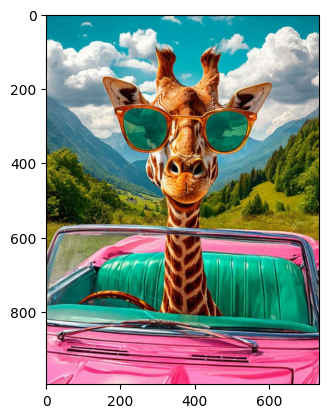

In [7]:
plt.imshow(imagen)
plt.show()

In [8]:
# Recortar la imagen
imagen_recortada = imagen[80:530, 150:610]  # Recortamos una porción de la imagen

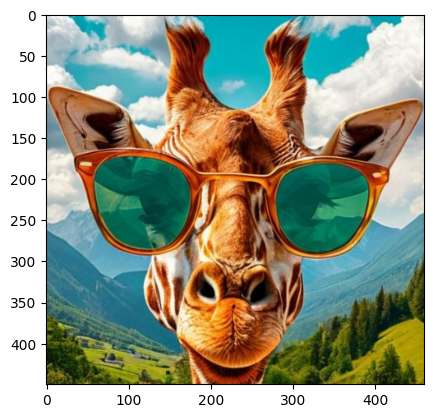

In [9]:
plt.imshow(imagen_recortada)
plt.show()

In [10]:
# Redimensionar la imagen
imagen_redimensionada = cv2.resize(imagen_recortada, (1000, 900))  # Cambiamos el tamaño

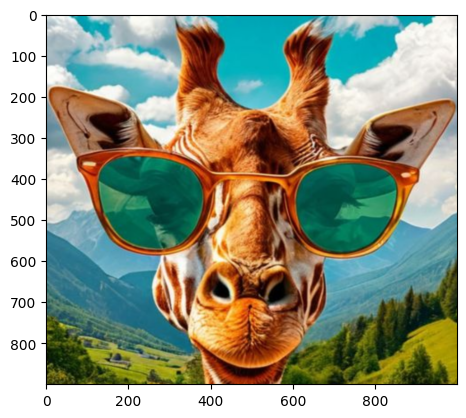

In [11]:
plt.imshow(imagen_redimensionada)
plt.show()

In [12]:
(alto, ancho) = imagen.shape[:2]
centro = (ancho / 2, alto / 2)
matriz_rotacion = cv2.getRotationMatrix2D(centro, 45, 1.0)  # Rotamos 45 grados, sin cambiar el tamaño
imagen_rotada = cv2.warpAffine(imagen_recortada, matriz_rotacion, (ancho, alto))

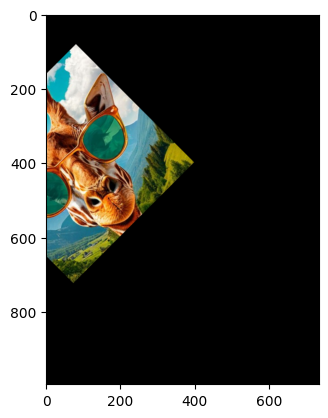

In [13]:
plt.imshow(imagen_rotada)
plt.show()

In [14]:
# Voltear la imagen
imagen_volteada_horizontal = cv2.flip(imagen_recortada, 1)  # Voltear horizontalmente
imagen_volteada_vertical = cv2.flip(imagen_recortada, 0)  # Voltear verticalmente
imagen_volteada_ambos = cv2.flip(imagen_recortada, -1) #voltear en ambos sentidos

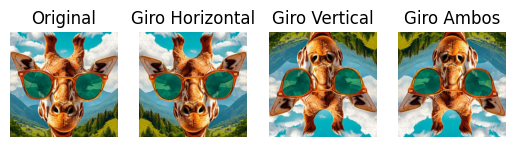

In [15]:
plt.subplot(1, 4, 1)
plt.imshow(imagen_recortada)
plt.title('Original')
axis = plt.axis('off')


# Mostrar los resultados
plt.subplot(1, 4, 2)
plt.imshow(imagen_volteada_horizontal)
plt.title('Giro Horizontal')
axis = plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(imagen_volteada_vertical)
plt.title('Giro Vertical')
axis = plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(imagen_volteada_ambos)
plt.title('Giro Ambos')
axis = plt.axis('off')

plt.show()

# 3. Mejora de la imagen

In [16]:
# Ajuste de brillo y contraste
def ajustar_brillo_contraste(imagen, brillo=0, contraste=1.0):
    imagen_ajustada = cv2.convertScaleAbs(imagen, alpha=contraste, beta=brillo)
    return imagen_ajustada

In [17]:
imagen_brillo_mas_50 = ajustar_brillo_contraste(imagen, brillo=50)
imagen_contraste_x1_5 = ajustar_brillo_contraste(imagen, contraste=1.5)

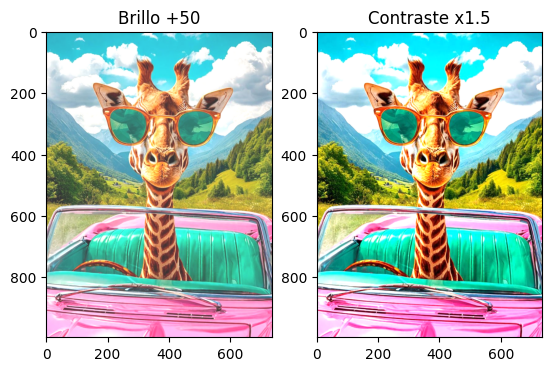

In [18]:
plt.subplot(1, 2, 1)
plt.imshow(imagen_brillo_mas_50)
plt.title('Brillo +50')

plt.subplot(1, 2, 2)
plt.imshow(imagen_contraste_x1_5)
plt.title('Contraste x1.5')

plt.show()

In [19]:
# Suavizado de la imagen (blur)
imagen_suavizada_media = cv2.blur(imagen, (5, 5))  # Promedio de los píxeles vecinos
imagen_suavizada_gaussiana = cv2.GaussianBlur(imagen, (5, 5), 0)  # Promedio ponderado (más peso a los píxeles cercanos)

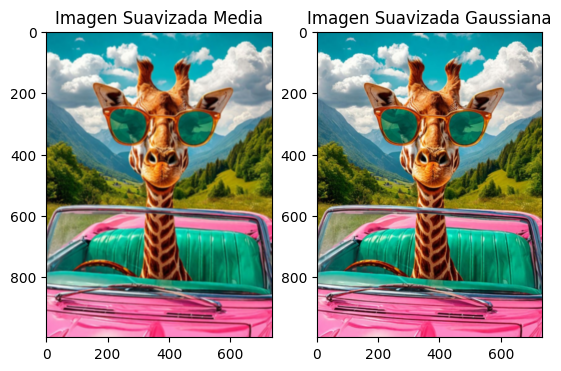

In [20]:
plt.subplot(1, 2, 1)
plt.imshow(imagen_suavizada_media)
plt.title('Imagen Suavizada Media')

plt.subplot(1, 2, 2)
plt.imshow(imagen_suavizada_gaussiana)
plt.title('Imagen Suavizada Gaussiana')

plt.show()

In [21]:
# Detección de bordes
imagen_gris = cv2.cvtColor(imagen, cv2.COLOR_RGB2GRAY)  # Convertimos a escala de grises para la detección de bordes
imagen_bordes_canny = cv2.Canny(imagen_gris, 100, 200)  # Detecta bordes en la imagen

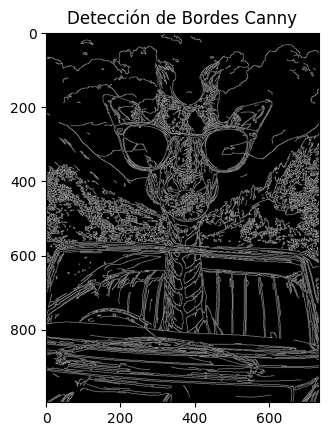

In [22]:
plt.imshow(imagen_bordes_canny, cmap='gray')
plt.title('Detección de Bordes Canny')
plt.show()

# 4. Segmentación de la imagen

In [23]:
# Segmentación: Dividir la imagen en regiones o partes más pequeñas.

# Umbralización: Convertir la imagen a blanco y negro
imagen_gris = cv2.cvtColor(imagen, cv2.COLOR_RGB2GRAY)
_, imagen_umbralizada = cv2.threshold(imagen_gris, 128, 255, cv2.THRESH_BINARY)
# El segundo valor (128) es el umbral.  Si el píxel es menor a 128, se vuelve negro (0), si es mayor, se vuelve blanco (255).

In [24]:
# Segmentación por color: Aislar objetos por su color (ejemplo: aislar el color verde mint)
imagen_hsv = cv2.cvtColor(imagen, cv2.COLOR_RGB2HSV)
limite_inferior_verde_mint = np.array([80, 100, 100])  # Rango inferior del color mint en HSV
limite_superior_verde_mint = np.array([120, 255, 255])  # Rango superior del color mint en HSV
mascara_verde_mint = cv2.inRange(imagen_hsv, limite_inferior_verde_mint, limite_superior_verde_mint)  # Crear una máscara para el color azul
imagen_segmentada_verde_mint = cv2.bitwise_and(imagen, imagen, mask=mascara_verde_mint)  # Aplicar la máscara a la imagen original

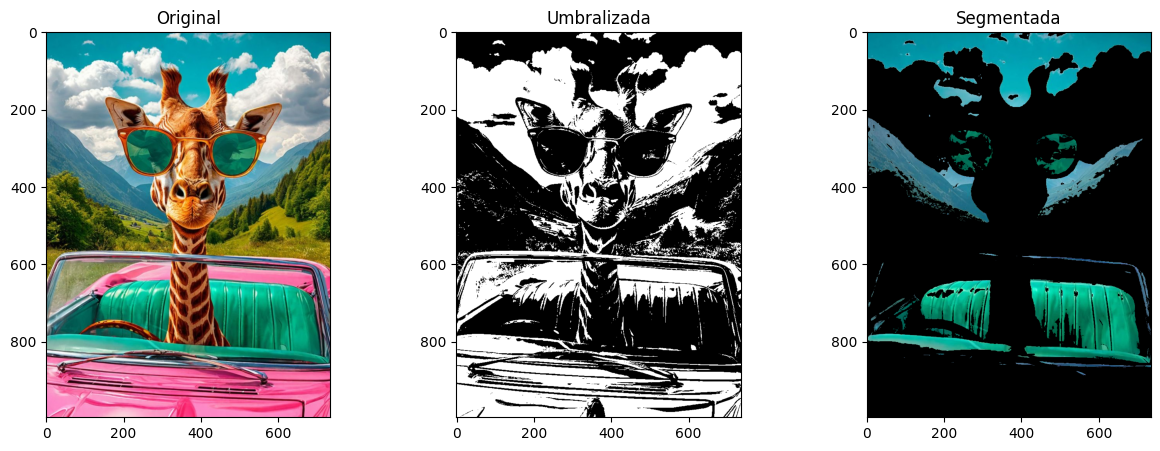

In [25]:
# Mostrar los resultados
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(imagen)
plt.title('Original')
plt.subplot(1, 3, 2)
plt.imshow(imagen_umbralizada, cmap='gray')
plt.title('Umbralizada')
plt.subplot(1, 3, 3)
plt.imshow(imagen_segmentada_verde_mint)
plt.title('Segmentada')
plt.show()

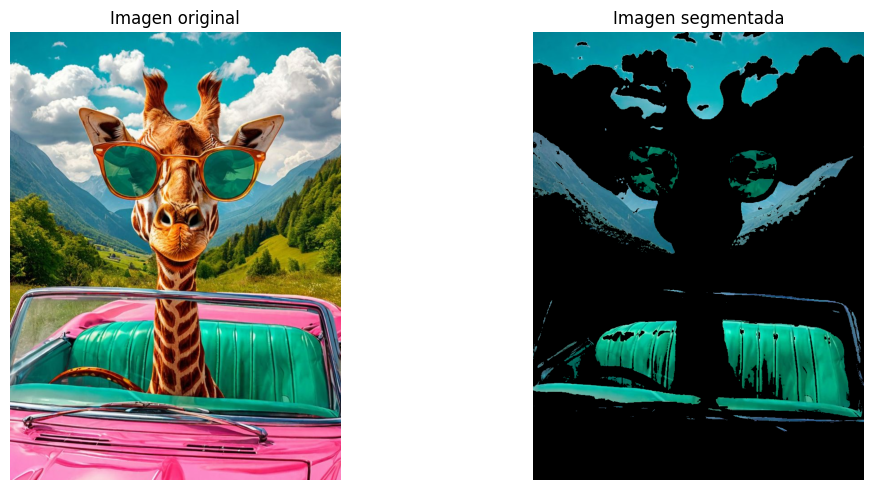

In [26]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Cargar la imagen
imagen_bgr = cv2.imread('jirafa.jpg')  # Asegúrate de que el archivo esté en la ruta correcta

# Convertir la imagen a HSV
imagen_hsv = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2HSV)

# Definir los límites inferior y superior para el color verde agua
limite_inferior_verde_agua = np.array([80, 100, 100])  # Rango inferior (H, S, V)
limite_superior_verde_agua = np.array([120, 255, 255])  # Rango superior (H, S, V)

# Crear la máscara para segmentar el verde agua
mascara_verde_agua = cv2.inRange(imagen_hsv, limite_inferior_verde_agua, limite_superior_verde_agua)

# Aplicar la máscara a la imagen original
resultado_verde_agua = cv2.bitwise_and(imagen_bgr, imagen_bgr, mask=mascara_verde_agua)

# Convertir la imagen original y segmentada a RGB para mostrar con Matplotlib
imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)
resultado_rgb = cv2.cvtColor(resultado_verde_agua, cv2.COLOR_BGR2RGB)

# Mostrar las imágenes
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(imagen_rgb)
plt.title("Imagen original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(resultado_rgb)
plt.title("Imagen segmentada")
plt.axis("off")

plt.tight_layout()
plt.show()


# 5. Transformaciones geométricas

In [27]:
# Escalado: Cambiar el tamaño de la imagen.
imagen_escalada_x2 = cv2.resize(imagen, (imagen.shape[1] * 2, imagen.shape[0] * 2))  # Duplicar el tamaño
imagen_escalada_mitad = cv2.resize(imagen, (imagen.shape[1] // 2, imagen.shape[0] // 2))  # Reducir a la mitad

Text(0.5, 1.0, 'Escalado /2')

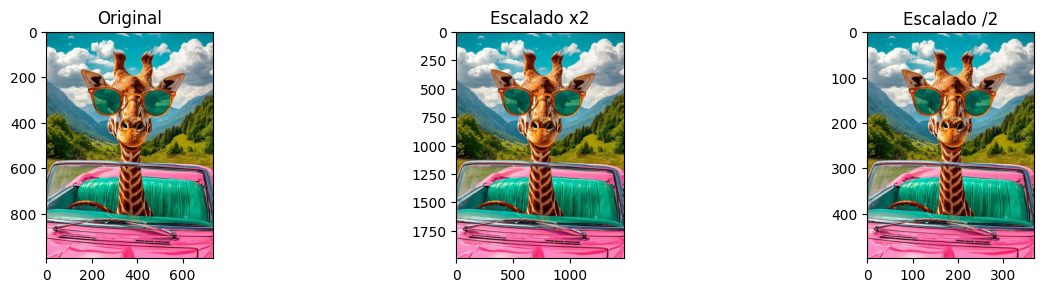

In [28]:
plt.figure(figsize=(15, 10))
plt.subplot(3, 3, 1)
plt.imshow(imagen)
plt.title('Original')
plt.subplot(3, 3, 2)
plt.imshow(imagen_escalada_x2)
plt.title('Escalado x2')
plt.subplot(3, 3, 3)
plt.imshow(imagen_escalada_mitad)
plt.title('Escalado /2')

In [29]:
# Traslación: Mover la imagen.
matriz_traslacion = np.float32([[1, 0, 50], [0, 1, 100]])  # Desplazar 50 a la derecha y 100 hacia abajo
imagen_trasladada = cv2.warpAffine(imagen, matriz_traslacion, (ancho, alto))

Text(0.5, 1.0, 'Traslación')

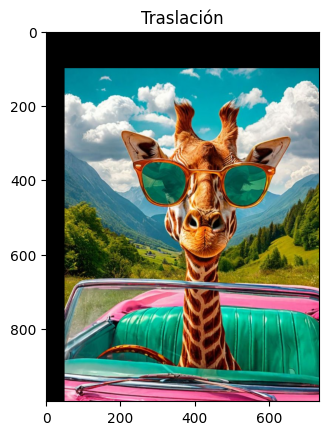

In [30]:
plt.imshow(imagen_trasladada)
plt.title('Traslación')

In [31]:
# Rotación: Girar la imagen.
matriz_rotacion = cv2.getRotationMatrix2D(centro, 45, 1.0)  # Rotar 45 grados alrededor del centro
imagen_rotada = cv2.warpAffine(imagen, matriz_rotacion, (ancho, alto))

Text(0.5, 1.0, 'Rotación')

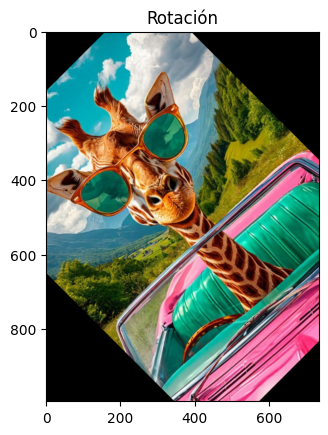

In [32]:
plt.imshow(imagen_rotada)
plt.title('Rotación')

In [33]:
# Transformaciones afines y de perspectiva (MUY BASICO)
# Transformación afín: Preserva las líneas rectas y el paralelismo.  Ej: rotación, traslación, escalado, cizalladura.
puntos_originales = np.float32([[50, 50], [200, 50], [50, 200]])
puntos_destino = np.float32([[100, 100], [300, 100], [100, 300]])
matriz_afin = cv2.getAffineTransform(puntos_originales, puntos_destino)
imagen_afin = cv2.warpAffine(imagen, matriz_afin, (ancho, alto))

Text(0.5, 1.0, 'Afín')

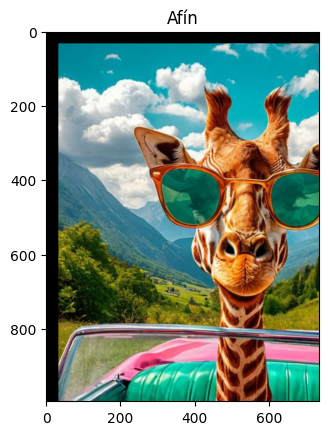

In [34]:
plt.imshow(imagen_afin)
plt.title('Afín')

In [35]:
# Transformación de perspectiva:  Las líneas rectas se mantienen, pero no necesariamente el paralelismo.
# Se usa para corregir la perspectiva de una imagen (ej: enderezar una foto de un documento).
puntos_originales_perspectiva = np.float32([[0, 0], [ancho - 1, 0], [0, alto - 1], [ancho - 1, alto - 1]])
puntos_destino_perspectiva = np.float32([[100, 50], [ancho + 50, 50], [50, alto - 50], [ancho + 100, alto - 100]])
matriz_perspectiva = cv2.getPerspectiveTransform(puntos_originales_perspectiva, puntos_destino_perspectiva)
imagen_perspectiva = cv2.warpPerspective(imagen, matriz_perspectiva, (ancho + 150, alto + 100))

Text(0.5, 1.0, 'Perspectiva')

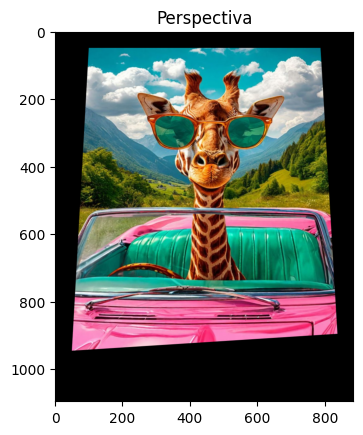

In [36]:
plt.imshow(imagen_perspectiva)
plt.title('Perspectiva')

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=9be9d3e5-4f25-48e6-912d-b59b8644d952' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>